# Customer Churn Prediction using Machine Learning
This notebook builds and evaluates classification models to predict customer churn.

## 1. Install and Import Required Libraries

In [1]:
!pip install catboost xgboost

In [2]:
!pip install torch

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch
import joblib

## 2. Load the Dataset

In [4]:
DATA_PATH = "Customer-Churn.csv"

## 3. Explore the Dataset

In [5]:
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Handle Missing Values and Data Cleaning

In [8]:
df = df[df["TotalCharges"] != " "]

In [9]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

## 5. Statistical Summary

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 6. Check Missing Values

In [11]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 7. Check Duplicate Records

In [12]:
df.duplicated().sum()

0

## 8. Exploratory Data Analysis (EDA)

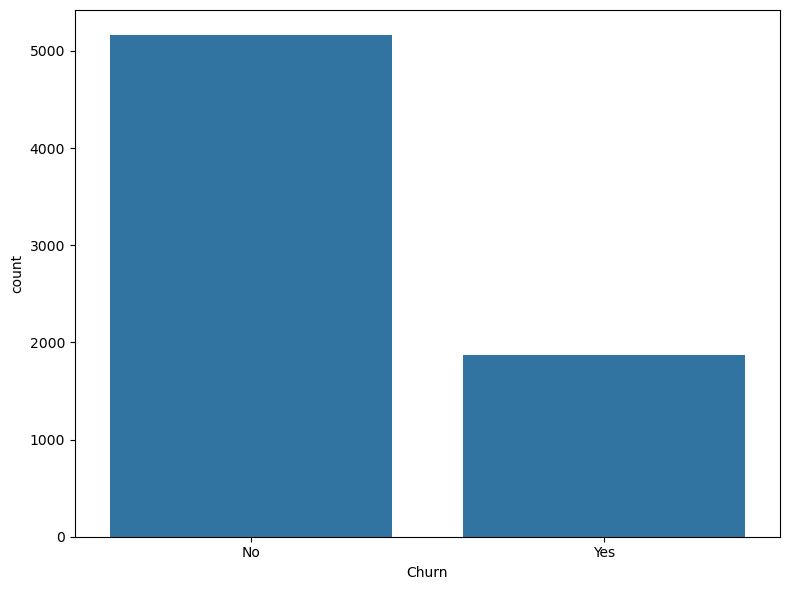

In [13]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="Churn")

plt.tight_layout()
plt.show()

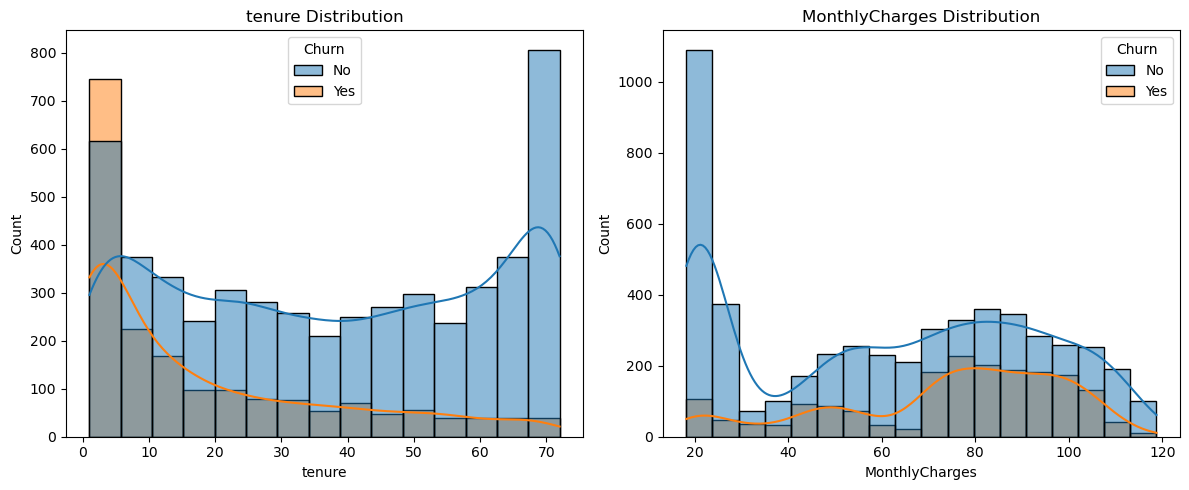

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for idx, col in enumerate(["tenure", "MonthlyCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax[idx])
    ax[idx].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

<Axes: >

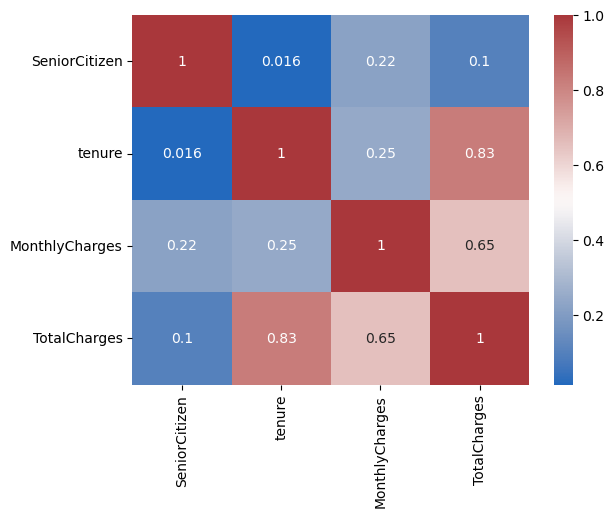

In [15]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

## 10. Feature Engineering and Encoding

In [16]:
df = df.drop(columns=["customerID"])

In [17]:
encoder = LabelEncoder()
df["Churn"] = encoder.fit_transform(df["Churn"])

In [18]:
cols = [col for col in df.select_dtypes("object")]

In [19]:
df = pd.get_dummies(data=df, columns=cols, drop_first=True)
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [20]:
bool_cols = [col for col in df.select_dtypes("bool")]
df[bool_cols] = df[bool_cols].astype(int)

## 11. Prepare Features and Target

In [21]:
x = df.drop(columns=["Churn"])
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=41, stratify=y_test)

## 12. Train Classification Models

In [22]:
rf = RandomForestClassifier(
    n_estimators=700,
    criterion="gini",
    random_state=41,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced"
)

svm = SVC(
    kernel="rbf",
    C=3,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=41,
    cache_size=2000
)

lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=2.76,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostClassifier(
    iterations=3700,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=8,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    random_strength=1.5,
    border_count=254
)

## 13. Train All Models

In [23]:
for model in [rf, svm, lr, xgb, cat]:
    model.fit(x_train, y_train)

0:	total: 141ms	remaining: 8m 42s
200:	total: 1.14s	remaining: 19.8s
400:	total: 2.12s	remaining: 17.5s
600:	total: 3.15s	remaining: 16.2s
800:	total: 4.24s	remaining: 15.4s
1000:	total: 5.28s	remaining: 14.2s
1200:	total: 6.29s	remaining: 13.1s
1400:	total: 7.31s	remaining: 12s
1600:	total: 8.32s	remaining: 10.9s
1800:	total: 9.32s	remaining: 9.83s
2000:	total: 10.4s	remaining: 8.8s
2200:	total: 11.4s	remaining: 7.74s
2400:	total: 12.4s	remaining: 6.7s
2600:	total: 13.4s	remaining: 5.66s
2800:	total: 14.4s	remaining: 4.63s
3000:	total: 15.5s	remaining: 3.6s
3200:	total: 16.5s	remaining: 2.57s
3400:	total: 17.5s	remaining: 1.54s
3600:	total: 18.6s	remaining: 511ms
3699:	total: 19.1s	remaining: 0us


## 14. Make Predictions

In [24]:
rf_predicted = rf.predict(x_test)
svm_predicted = svm.predict(x_test)
lr_predicted = lr.predict(x_test)
xgb_predicted = xgb.predict(x_test)
cat_predicted = cat.predict(x_test)

## 15. Classification Report (Accuracy, Precision, Recall, F1-score)

In [25]:
print("=========== Random Forest ===========\n")
print(classification_report(y_test, rf_predicted))
print("=========== Support Vector Machine ===========\n")
print(classification_report(y_test, svm_predicted))
print("=========== Logistic Regression ===========\n")
print(classification_report(y_test, lr_predicted))
print("=========== XGBoost Classifier ===========\n")
print(classification_report(y_test, xgb_predicted))
print("=========== CatBoost Classifier ===========\n")
print(classification_report(y_test, cat_predicted))

=========== Random Forest ===========

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       512
           1       0.56      0.73      0.64       192

    accuracy                           0.77       704
   macro avg       0.72      0.76      0.73       704
weighted avg       0.80      0.77      0.78       704

=========== Support Vector Machine ===========

              precision    recall  f1-score   support

           0       0.85      0.69      0.76       512
           1       0.45      0.67      0.54       192

    accuracy                           0.69       704
   macro avg       0.65      0.68      0.65       704
weighted avg       0.74      0.69      0.70       704

=========== Logistic Regression ===========

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       512
           1       0.51      0.83      0.63       192

    accuracy                           0.74       

## 16. ROC-AUC Evaluation

In [26]:
from sklearn.metrics import roc_auc_score

# Probability predictions
rf_prob = rf.predict_proba(x_test)[:, 1]
lr_prob = lr.predict_proba(x_test)[:, 1]

print("========== ROC-AUC Score ==========\n")

print("Random Forest :", roc_auc_score(y_test, rf_prob))
print("Logistic Regression :", roc_auc_score(y_test, lr_prob))

========== ROC-AUC Score ==========

Random Forest : 0.8474121093749999
Logistic Regression : 0.8504435221354166


## 17. ROC Curves

<Figure size 600x500 with 0 Axes>

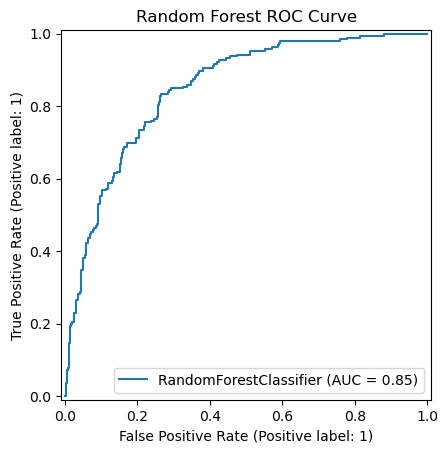

<Figure size 600x500 with 0 Axes>

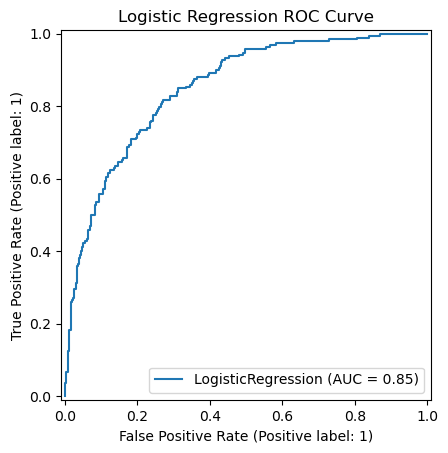

In [27]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(rf, x_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(lr, x_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

## 18. Confusion Matrices

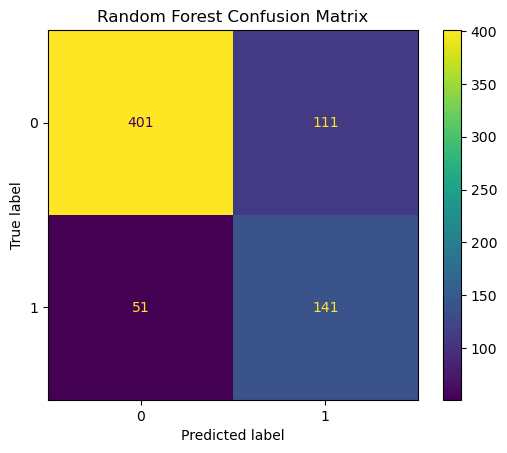

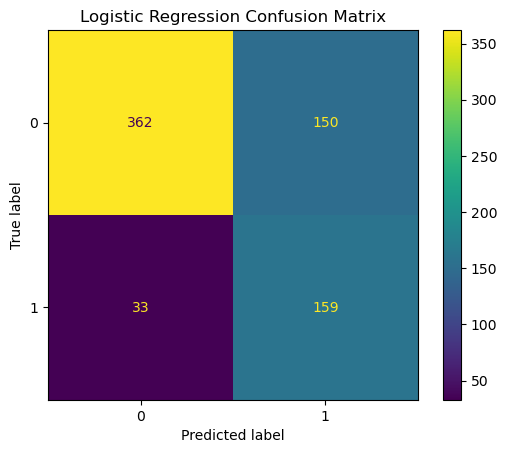

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(lr, x_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 19. 5-Fold Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score

print("========== Cross Validation ==========\n")

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=5, scoring="accuracy")

    print(name)
    print("Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print()

========== Cross Validation ==========

Logistic Regression
Scores: [0.74911158 0.7583511  0.73968706 0.74466572 0.75035562]
Mean Accuracy: 0.7484342158340588

Random Forest
Scores: [0.77469794 0.78535892 0.75889047 0.77311522 0.78449502]
Mean Accuracy: 0.7753115139603748



## 20. Conclusion
Random Forest and Logistic Regression are compared as primary models. Evaluation includes Accuracy, Precision, Recall, F1-score, ROC-AUC, ROC Curves and 5-fold Cross Validation.